# Обучение модели прогноза урожайности (LightGBM)

**Модель:** LightGBM Regressor  
**Целевая переменная:** `yield_centners_per_ha` — урожайность в центнерах/га  
**Охват:** 76 регионов России, 13 сельскохозяйственных культур, данные с 2000 по 2024 г.  
**Валидация:** LOYO (Leave-One-Year-Out) — на каждой итерации обучаем только на годах до тестового

---

## Структура ноутбука
1. Загрузка и первичный анализ данных
2. Feature engineering — описание признаков
3. Кодирование категориальных признаков
4. LOYO кросс-валидация
5. Финальная модель на всех данных
6. Feature importance
7. Сохранение артефактов

In [ ]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import datetime
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')

# Ноутбук лежит в agro-ml-service/notebooks/
# DATA_DIR = agro-ml-service/data/
NOTEBOOK_DIR = Path('.').resolve()
SERVICE_DIR = NOTEBOOK_DIR.parent
DATA_DIR = SERVICE_DIR / 'data'
MODELS_DIR = SERVICE_DIR / 'models'
MODELS_DIR.mkdir(exist_ok=True)

HARVEST_CSV = DATA_DIR / 'harvest_master.csv'

print('Библиотеки загружены')
print(f'LightGBM версия: {lgb.__version__}')
print(f'Файл данных   : {HARVEST_CSV.resolve()}')
print(f'Папка моделей : {MODELS_DIR.resolve()}')

Библиотеки загружены
LightGBM версия: 4.6.0
Файл данных   : C:\Users\nikit\IdeaProjects\AgroPlanPro\agro-ml-service\notebooks\models\harvest_master.csv
Папка моделей : C:\Users\nikit\IdeaProjects\AgroPlanPro\agro-ml-service\models


In [ ]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import datetime
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')

# Ноутбук лежит в agro-ml-service/notebooks/
# DATA_DIR = agro-ml-service/data/
NOTEBOOK_DIR = Path('.').resolve()
SERVICE_DIR = NOTEBOOK_DIR.parent
DATA_DIR = SERVICE_DIR / 'data'
MODELS_DIR = (SERVICE_DIR / 'models').resolve()
MODELS_DIR.mkdir(exist_ok=True)

HARVEST_CSV = DATA_DIR / 'harvest_master.csv'

print('Библиотеки загружены')
print(f'LightGBM версия: {lgb.__version__}')
print(f'Файл данных   : {HARVEST_CSV.resolve()}')
print(f'Папка моделей : {MODELS_DIR.resolve()}')

Библиотеки загружены
LightGBM версия: 4.6.0
Файл данных   : C:\Users\nikit\IdeaProjects\AgroPlanPro\agro-ml-service\notebooks\models\harvest_master.csv
Папка моделей : C:\Users\nikit\IdeaProjects\AgroPlanPro\agro-ml-service\models


## 1. Загрузка и первичный анализ данных

`harvest_master.csv` — основная таблица с историческими данными по урожайности.
Каждая строка соответствует паре (регион, культура, год).
Помимо самой урожайности в ней уже посчитаны лаговые и погодные признаки.

In [3]:
df = pd.read_csv(HARVEST_CSV)

print(f'Всего строк       : {len(df):,}')
print(f'Культур           : {df["crop"].nunique()} — {sorted(df["crop"].unique())}')
print(f'Регионов          : {df["region"].nunique()}')
print(f'Годы              : {df["year"].min()} – {df["year"].max()}')
print(f'Целевая переменная: min={df["yield_centners_per_ha"].min():.1f}, '
      f'max={df["yield_centners_per_ha"].max():.1f}, '
      f'mean={df["yield_centners_per_ha"].mean():.1f}')

df.head()

Всего строк       : 10,124
Культур           : 13 — ['buckwheat', 'flax', 'oat', 'rapeseed', 'spring_barley', 'spring_rapeseed', 'spring_rye', 'spring_wheat', 'sunflower', 'winter_barley', 'winter_rapeseed', 'winter_rye', 'winter_wheat']
Регионов          : 76
Годы              : 2010 – 2024
Целевая переменная: min=0.3, max=201.4, mean=18.2


,region,region_code,crop,year,yield_centners_per_ha,sown_area_thou_ha,production_thou_centners,has_sown_area,precip_oct_mar,precip_apr_may,...,yield_ma3,yield_ma5,yield_ma10,yield_idx_ma5,yield_idx_ma10,yield_yoy,yield_volatility,yield_cv,production_yoy,area_yoy
0,Алтайский край,ALT,buckwheat,2010,7.5,341.28,255.9600,True,212.0,63.0,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.777817,0.0,0.000000,0.000000
1,Алтайский край,ALT,buckwheat,2011,8.6,422.23,363.1178,True,190.5,80.8,...,0.000000,0.0,0.0,0.0,0.0,0.146667,0.777817,0.0,0.418651,0.237195
2,Алтайский край,ALT,buckwheat,2012,7.1,494.35,350.9885,True,99.2,50.2,...,0.000000,0.0,0.0,0.0,0.0,-0.174419,0.777817,0.0,-0.033403,0.170807
3,Алтайский край,ALT,buckwheat,2013,8.0,489.82,391.8560,True,285.5,148.4,...,7.733333,0.0,0.0,0.0,0.0,0.126761,0.776745,0.0,0.116435,-0.009164
4,Алтайский край,ALT,buckwheat,2014,9.5,464.41,441.1895,True,185.9,72.7,...,7.900000,0.0,0.0,0.0,0.0,0.187500,0.648074,0.0,0.125897,-0.051876


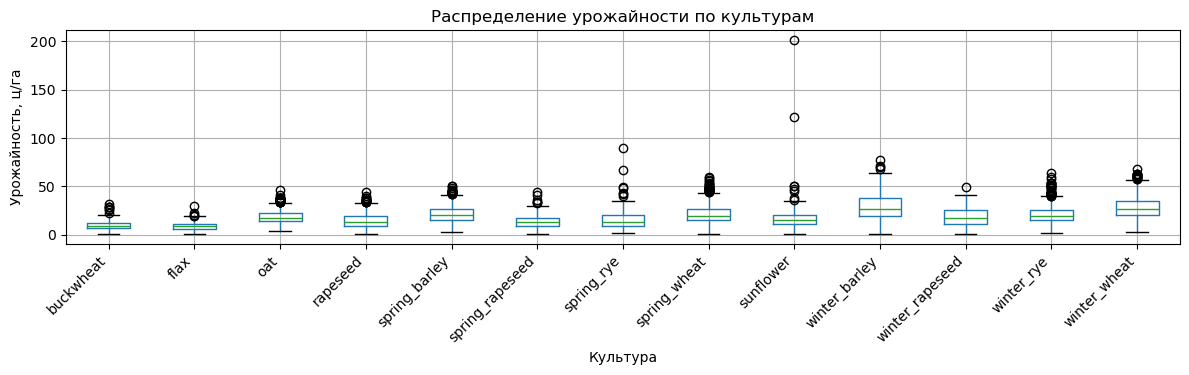

In [4]:
# Распределение урожайности по культурам
fig, ax = plt.subplots(figsize=(12, 4))
df.boxplot(column='yield_centners_per_ha', by='crop', ax=ax)
ax.set_title('Распределение урожайности по культурам')
ax.set_xlabel('Культура')
ax.set_ylabel('Урожайность, ц/га')
plt.suptitle('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [5]:
# Пропущенные значения по ключевым столбцам
key_cols = [
    'yield_centners_per_ha',
    'yield_lag1', 'yield_lag2', 'yield_ma3', 'yield_ma5',
    'precip_oct_mar', 'precip_apr_may', 'precip_jun_jul', 'precip_aug_sep',
    'temp_sum_apr_may', 'temp_sum_jun_jul', 'temp_sum_aug_sep',
    'soil_ph_mean', 'soil_soc_mean', 'soil_nitrogen_mean',
]
missing = df[key_cols].isna().mean().sort_values(ascending=False)
print('Доля пропусков по ключевым признакам:')
print(missing[missing > 0].apply(lambda x: f'{x:.1%}').to_string())

Доля пропусков по ключевым признакам:
Series([], )


## 2. Описание признаков

| Группа | Признаки | Описание |
|--------|----------|----------|
| Категориальные | `crop`, `region_code` | Культура и код региона (label-encoded) |
| Лаги урожайности | `yield_lag1`, `yield_lag2` | Урожайность за 1 и 2 года до целевого |
| Скользящие средние | `yield_ma3`, `yield_ma5` | Средняя за 3 и 5 лет |
| Тренд | `yield_yoy`, `yield_volatility`, `yield_cv` | Год-к-году, волатильность, коэф. вариации |
| Погода (сырая) | `precip_oct_mar/apr_may/jun_jul/aug_sep` | Осадки по сезонным периодам, мм |
| | `temp_sum_apr_may/jun_jul/aug_sep/apr_sep` | Сумма температур по периодам, градусо-дни |
| Погодные аномалии | `*_zscore` | Z-оценка относительно многолетней нормы |
| Засуха | `drought_index`, `weather_favorability` | Индекс засухи и благоприятности погоды |
| Почва | `soil_ph_mean`, `soil_soc_mean`, ... | Данные SoilGrids по каждому региону |
| Посевные площади | `sown_area_thou_ha`, `area_yoy` | Тыс. га и год-к-году тренд площадей |

## 3. Подготовка данных

In [6]:
# Набор числовых признаков — полный список из train_models.py
YIELD_NUMERIC = [
    'yield_lag1', 'yield_lag2', 'yield_ma3', 'yield_ma5',
    'yield_yoy', 'yield_volatility', 'yield_cv',
    'precip_oct_mar', 'precip_apr_may', 'precip_jun_jul', 'precip_aug_sep',
    'temp_sum_apr_may', 'temp_sum_jun_jul', 'temp_sum_aug_sep', 'temp_sum_apr_sep',
    'precip_oct_mar_zscore', 'precip_apr_may_zscore',
    'precip_jun_jul_zscore', 'precip_aug_sep_zscore',
    'temp_sum_apr_may_zscore', 'temp_sum_jun_jul_zscore', 'temp_sum_aug_sep_zscore',
    'drought_index', 'weather_favorability',
    'soil_ph_mean', 'soil_soc_mean', 'soil_nitrogen_mean',
    'soil_clay_mean', 'soil_sand_mean', 'soil_bdod_mean', 'soil_type_code',
    # Посевные площади
    'sown_area_thou_ha', 'area_yoy',
]
YIELD_CAT    = ['crop', 'region_code']
YIELD_TARGET = 'yield_centners_per_ha'

# Оставляем только существующие в датасете столбцы
y_num_cols  = [c for c in YIELD_NUMERIC if c in df.columns]
y_all_feats = YIELD_CAT + y_num_cols

# Убираем строки без целевой переменной
df_model = df.dropna(subset=[YIELD_TARGET]).copy()

# Клипинг выбросов area_yoy (диапазон [-1, 2] покрывает экономически реальные изменения)
if 'area_yoy' in df_model.columns:
    df_model['area_yoy'] = df_model['area_yoy'].clip(-1.0, 2.0)

# Пропуски в числовых признаках заполняем медианой по культуре
for col in y_num_cols:
    if df_model[col].isna().any():
        df_model[col] = df_model.groupby('crop')[col].transform(
            lambda x: x.fillna(x.median())
        )
        df_model[col] = df_model[col].fillna(0)

print(f'Строк после фильтрации: {len(df_model):,}')
print(f'Признаков: {len(y_all_feats)} ({len(YIELD_CAT)} категориальных + {len(y_num_cols)} числовых)')
print(f'Новые признаки площадей: {[c for c in ["sown_area_thou_ha", "area_yoy"] if c in y_num_cols]}')
print(f'area_yoy после клипинга: min={df_model["area_yoy"].min():.2f}, max={df_model["area_yoy"].max():.2f}')

Строк после фильтрации: 10,124
Признаков: 35 (2 категориальных + 33 числовых)
Новые признаки площадей: ['sown_area_thou_ha', 'area_yoy']
area_yoy после клипинга: min=-1.00, max=2.00


In [7]:
# LabelEncoder для категориальных признаков
# Обучаем на ВСЕХ данных — одинаковый энкодер используется и при обучении, и при инференсе
y_encoders = {}
for col in YIELD_CAT:
    le = LabelEncoder()
    le.fit(df_model[col].astype(str))
    y_encoders[col] = le

df_enc = df_model.copy()
for col, le in y_encoders.items():
    df_enc[col] = le.transform(df_enc[col].astype(str))

print('Энкодеры обучены:')
for col, le in y_encoders.items():
    print(f'  {col}: {list(le.classes_)}')

Энкодеры обучены:
  crop: ['buckwheat', 'flax', 'oat', 'rapeseed', 'spring_barley', 'spring_rapeseed', 'spring_rye', 'spring_wheat', 'sunflower', 'winter_barley', 'winter_rapeseed', 'winter_rye', 'winter_wheat']
  region_code: ['AD', 'AL', 'ALT', 'AMU', 'ARK', 'AST', 'BA', 'BEL', 'BRY', 'BU', 'CE', 'CHE', 'CR', 'CU', 'DA', 'IN', 'IRK', 'IVA', 'KAM', 'KAR', 'KB', 'KC', 'KDA', 'KEM', 'KGD', 'KGN', 'KHA', 'KHM', 'KIR', 'KK', 'KL', 'KLU', 'KOM', 'KOS', 'KRS', 'KYA', 'LEN', 'LIP', 'ME', 'MO', 'MOS', 'NGR', 'NIZ', 'NVS', 'OMS', 'ORE', 'ORL', 'PER', 'PNZ', 'PRI', 'PSK', 'ROS', 'RYA', 'SA', 'SAM', 'SAR', 'SE', 'SMO', 'STA', 'SVE', 'TA', 'TAM', 'TOM', 'TUL', 'TVE', 'TY', 'TYU', 'UD', 'ULY', 'VGG', 'VLA', 'VOL', 'VOR', 'YAR', 'YEV', 'ZAB']


## 4. LOYO кросс-валидация

**LOYO (Leave-One-Year-Out)** — честная временная валидация:
- На каждой итерации обучаем только на данных **строго до** тестового года
- Это имитирует реальное использование: модель никогда не видит будущее
- Целевая переменная логарифмируется (`log1p`) для стабилизации дисперсии
- Early stopping на предпоследнем году обучающей выборки

In [8]:
# Гиперпараметры LightGBM
LGBM_PARAMS = dict(
    objective='regression',
    metric='rmse',
    num_leaves=63,
    learning_rate=0.05,
    n_estimators=800,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred):
    return float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100)

def train_lgbm(X_train, y_train, X_val, y_val, params):
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(0),
        ],
    )
    return model

print('Гиперпараметры и вспомогательные функции готовы')

Гиперпараметры и вспомогательные функции готовы


In [9]:
years    = sorted(df_enc['year'].unique())
cv_rows  = []

# Тестируем начиная с 2014 года — до этого слишком мало данных для обучения
test_years = [y for y in years if y >= 2014]

print(f'{'Год':>6} | {'R2':>7} | {'RMSE':>7} | {'MAE':>6} | {'MAPE%':>6} | {'n':>5}')
print('-' * 52)

for test_year in test_years:
    # Обучающая выборка: все годы СТРОГО до test_year
    tr = df_enc[df_enc['year'] < test_year].copy()
    te = df_enc[df_enc['year'] == test_year].copy()

    if len(te) < 10 or len(tr) < 100:
        continue

    # Предпоследний год обучающей выборки — для early stopping
    eval_year = sorted(tr['year'].unique())[-1]
    tr_fit = tr[tr['year'] != eval_year]
    tr_val = tr[tr['year'] == eval_year]

    # Логарифмируем целевую переменную: log1p стабилизирует дисперсию
    y_tr  = np.log1p(tr_fit[YIELD_TARGET].values)
    y_val = np.log1p(tr_val[YIELD_TARGET].values)
    y_te  = te[YIELD_TARGET].values

    model = train_lgbm(tr_fit[y_all_feats], y_tr,
                       tr_val[y_all_feats], y_val, LGBM_PARAMS)

    # Обратное преобразование: expm1 = exp(x) - 1
    pred = np.expm1(model.predict(te[y_all_feats]))

    r2_val = r2_score(y_te, pred)
    cv_rows.append({
        'year': test_year,
        'r2':   r2_val,
        'rmse': rmse(y_te, pred),
        'mae':  mean_absolute_error(y_te, pred),
        'mape': mape(y_te, pred),
        'n':    len(te),
    })
    print(f'{test_year:>6} | {r2_val:>7.4f} | {rmse(y_te, pred):>7.2f} | '
          f'{mean_absolute_error(y_te, pred):>6.2f} | {mape(y_te, pred):>6.1f} | {len(te):>5}')

cv_df = pd.DataFrame(cv_rows)
print('-' * 52)
print(f'{'MEAN':>6} | {cv_df["r2"].mean():>7.4f} | {cv_df["rmse"].mean():>7.2f} | '
      f'{cv_df["mae"].mean():>6.2f} | {cv_df["mape"].mean():>6.1f}')
print(f'\nCV R2 = {cv_df["r2"].mean():.4f}  (LOYO, out-of-sample, year < test_year)')

   Год |      R2 |    RMSE |    MAE |  MAPE% |     n
----------------------------------------------------
  2014 |  0.9247 |    2.46 |   1.47 |   11.4 |   647
  2015 |  0.8800 |    3.20 |   1.52 |    9.5 |   645
  2016 |  0.5609 |    8.07 |   1.39 |    6.6 |   684
  2017 |  0.9848 |    1.24 |   0.71 |    4.1 |   672
  2018 |  0.9803 |    1.28 |   0.65 |    7.2 |   660
  2019 |  0.9737 |    1.58 |   0.71 |    4.5 |   675
  2020 |  0.9887 |    1.16 |   0.65 |    3.5 |   667
  2021 |  0.9892 |    0.99 |   0.54 |    3.6 |   667
  2022 |  0.9759 |    1.80 |   0.83 |    4.4 |   724
  2023 |  0.9590 |    2.39 |   0.76 |    4.1 |   721
  2024 |  0.9788 |    1.47 |   0.65 |    6.7 |   722
----------------------------------------------------
  MEAN |  0.9269 |    2.33 |   0.90 |    6.0

CV R2 = 0.9269  (LOYO, out-of-sample, year < test_year)


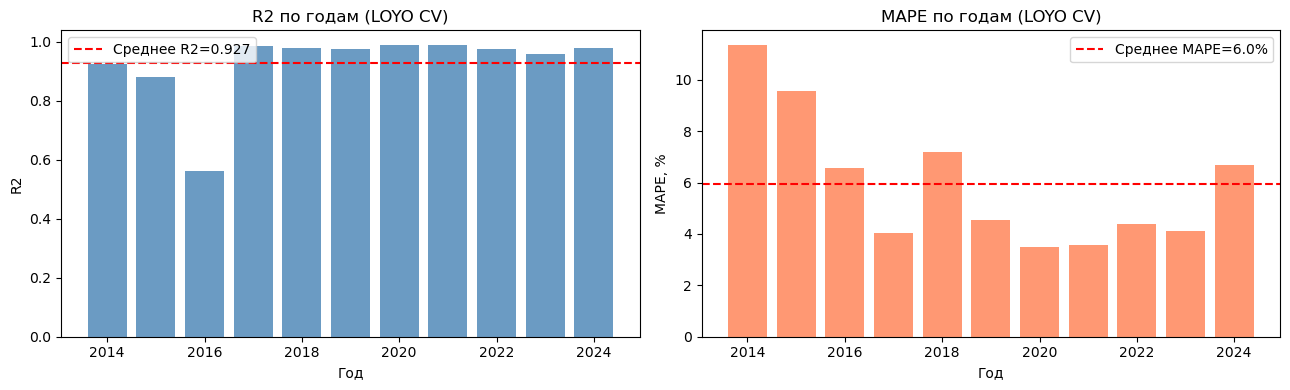

In [10]:
# Визуализация CV-метрик по годам
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(cv_df['year'], cv_df['r2'], color='steelblue', alpha=0.8)
axes[0].axhline(cv_df['r2'].mean(), color='red', linestyle='--', label=f'Среднее R2={cv_df["r2"].mean():.3f}')
axes[0].set_title('R2 по годам (LOYO CV)')
axes[0].set_xlabel('Год')
axes[0].set_ylabel('R2')
axes[0].legend()

axes[1].bar(cv_df['year'], cv_df['mape'], color='coral', alpha=0.8)
axes[1].axhline(cv_df['mape'].mean(), color='red', linestyle='--', label=f'Среднее MAPE={cv_df["mape"].mean():.1f}%')
axes[1].set_title('MAPE по годам (LOYO CV)')
axes[1].set_xlabel('Год')
axes[1].set_ylabel('MAPE, %')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Финальная модель на всех данных

После подбора гиперпараметров через LOYO CV обучаем финальную модель на **всём датасете**.
Последний год используется для early stopping, но не исключается из обучения.

In [11]:
last_year = sorted(df_enc['year'].unique())[-1]
tr_all    = df_enc[df_enc['year'] != last_year]
val_all   = df_enc[df_enc['year'] == last_year]

final_yield = train_lgbm(
    tr_all[y_all_feats],  np.log1p(tr_all[YIELD_TARGET].values),
    val_all[y_all_feats], np.log1p(val_all[YIELD_TARGET].values),
    LGBM_PARAMS,
)

# In-sample R2 — только для справки, НЕ является метрикой качества
y_insample_pred = np.expm1(final_yield.predict(df_enc[y_all_feats]))
y_insample_r2   = r2_score(df_enc[YIELD_TARGET].values, y_insample_pred)

print(f'Финальная модель обучена')
print(f'  CV R2 (out-of-sample) = {cv_df["r2"].mean():.4f}  <- основная метрика')
print(f'  In-sample R2          = {y_insample_r2:.4f}  <- только для справки')
print(f'  Деревьев (best iteration): {final_yield.best_iteration_}')

Финальная модель обучена
  CV R2 (out-of-sample) = 0.9269  <- основная метрика
  In-sample R2          = 0.9613  <- только для справки
  Деревьев (best iteration): 132


## 6. Важность признаков

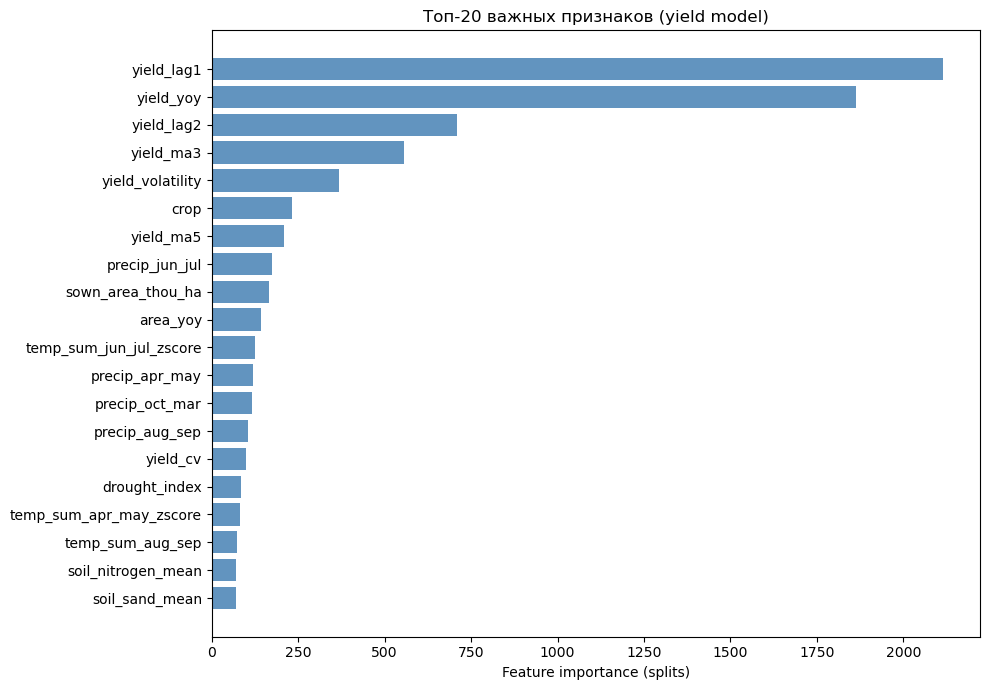

Топ-10 признаков:
          feature  importance
       yield_lag1        2116
        yield_yoy        1862
       yield_lag2         709
        yield_ma3         556
 yield_volatility         367
             crop         231
        yield_ma5         210
   precip_jun_jul         173
sown_area_thou_ha         165
         area_yoy         142


In [12]:
y_imp = pd.DataFrame({
    'feature':    y_all_feats,
    'importance': final_yield.feature_importances_,
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top_n = y_imp.head(20)
ax.barh(top_n['feature'][::-1], top_n['importance'][::-1], color='steelblue', alpha=0.85)
ax.set_title('Топ-20 важных признаков (yield model)')
ax.set_xlabel('Feature importance (splits)')
plt.tight_layout()
plt.show()

print('Топ-10 признаков:')
print(y_imp.head(10).to_string(index=False))

## 7. Сохранение артефактов

In [13]:
# Сохраняем модель
joblib.dump(final_yield, MODELS_DIR / 'yield_model.pkl')

# Сохраняем энкодеры — они нужны при инференсе для encode тех же категорий
joblib.dump(y_encoders, MODELS_DIR / 'yield_encoders.pkl')

# Сохраняем таблицу важностей
y_imp.to_csv(MODELS_DIR / 'yield_feature_importance.csv', index=False)

# Сохраняем метаданные: список признаков, метрики, параметры
# Этот JSON читается при старте сервиса для /api/yield/info
yield_meta = {
    'features_numeric': y_num_cols,
    'features_cat':     YIELD_CAT,
    'features_all':     y_all_feats,
    'target':           YIELD_TARGET,
    'log_target':       True,
    'cv_r2_mean':       round(float(cv_df['r2'].mean()), 4),
    'cv_rmse_mean':     round(float(cv_df['rmse'].mean()), 4),
    'cv_mape_mean':     round(float(cv_df['mape'].mean()), 2),
    'cv_type':          'LOYO (year < test_year, out-of-sample)',
    'in_sample_r2':     round(float(y_insample_r2), 4),
    'trained_at':       datetime.now().isoformat(),
    'n_train':          int(len(df_model)),
    'years':            f"{int(df_model['year'].min())}-{int(df_model['year'].max())}",
    'crops':            sorted(df_model['crop'].unique().tolist()),
    'n_regions':        int(df_model['region_code'].nunique()),
    'top5_features':    y_imp['feature'].head(5).tolist(),
}

with open(MODELS_DIR / 'yield_meta.json', 'w', encoding='utf-8') as f:
    json.dump(yield_meta, f, ensure_ascii=False, indent=2)

print('Артефакты сохранены в', MODELS_DIR.resolve())
print(f'  yield_model.pkl             — LightGBM модель')
print(f'  yield_encoders.pkl          — LabelEncoder для crop и region_code')
print(f'  yield_meta.json             — метрики и список признаков')
print(f'  yield_feature_importance.csv')
print(f'\nCV R2  = {cv_df["r2"].mean():.4f}')
print(f'CV RMSE= {cv_df["rmse"].mean():.2f} ц/га')
print(f'CV MAPE= {cv_df["mape"].mean():.1f}%')

Артефакты сохранены в C:\Users\nikit\IdeaProjects\AgroPlanPro\agro-ml-service\models
  yield_model.pkl             — LightGBM модель
  yield_encoders.pkl          — LabelEncoder для crop и region_code
  yield_meta.json             — метрики и список признаков
  yield_feature_importance.csv

CV R2  = 0.9269
CV RMSE= 2.33 ц/га
CV MAPE= 6.0%


## Пример инференса

Демонстрируем, как модель используется сервисом при поступлении запроса.

In [16]:
# Загружаем сохранённые артефакты (как это делает agro-ml-service при старте)
model_loaded    = joblib.load(MODELS_DIR / 'yield_model.pkl')
encoders_loaded = joblib.load(MODELS_DIR / 'yield_encoders.pkl')
with open(MODELS_DIR / 'yield_meta.json', encoding='utf-8') as f:
    meta_loaded = json.load(f)

def predict_yield(crop, region_code, year, weather=None):
    """
    Прогноз урожайности с автоподстановкой лаговых признаков из датасета.
    weather — dict с погодными ключами (опционально).
    """
    # Берём последнюю известную строку для данной пары (регион, культура)
    hist = df[
        (df['region_code'] == region_code) & (df['crop'] == crop)
    ].sort_values('year')

    # Собираем признаки из последней исторической строки (лаги, скользящие, почва и т.д.)
    base = {}
    if len(hist) > 0:
        last_row = hist.iloc[-1]
        for feat in meta_loaded['features_numeric']:
            base[feat] = float(last_row.get(feat, 0) or 0)
        # Сдвигаем лаги вперёд: lag1 <- последний известный урожай
        last_yield = float(last_row['yield_centners_per_ha'])
        base['yield_lag1'] = last_yield
        if 'yield_lag1' in last_row:
            base['yield_lag2'] = float(last_row['yield_lag1'] or 0)
        # yield_yoy относительно lag1
        if base.get('yield_lag2', 0) > 0:
            base['yield_yoy'] = (base['yield_lag1'] - base['yield_lag2']) / base['yield_lag2']

    # Перезаписываем погодными данными, если переданы
    if weather:
        base.update(weather)

    # Категориальные признаки
    sample = dict(base)
    sample['crop'] = crop
    sample['region_code'] = region_code

    for col, le in encoders_loaded.items():
        val = str(sample.get(col, ''))
        if val not in set(le.classes_):
            val = le.classes_[0]
        sample[col] = int(le.transform([val])[0])

    X = pd.DataFrame([{f: sample.get(f, 0) for f in meta_loaded['features_all']}])
    pred_val = float(np.expm1(model_loaded.predict(X)[0]))
    return pred_val

# --- Пример 1: Алтайский край, озимая пшеница, с погодой ---
weather_alt = {
    'precip_oct_mar': 95.0, 'precip_apr_may': 68.0,
    'precip_jun_jul': 85.0, 'precip_aug_sep': 55.0,
    'temp_sum_apr_may': 420.0, 'temp_sum_jun_jul': 920.0,
    'temp_sum_aug_sep': 680.0, 'temp_sum_apr_sep': 2020.0,
}
p1 = predict_yield('winter_wheat', 'ALT', 2025, weather=weather_alt)
print(f'ALT, winter_wheat, с погодой  : {p1:.1f} ц/га')

# --- Пример 2: Омская область, яровая пшеница, без погоды ---
p2 = predict_yield('spring_wheat', 'OMS', 2025)
print(f'OMS, spring_wheat, без погоды : {p2:.1f} ц/га')

ALT, winter_wheat, с погодой  : 45.7 ц/га
OMS, spring_wheat, без погоды : 32.1 ц/га
